# Replication completion bounds on the line and the torus

This notebook is the executable analysis record for the workflow described in the README. Starting from Repli-seq timing tracks, it extracts timing profiles, fits initiation-rate landscapes, runs stochastic replication simulations, and compares completion-time statistics with the analytical bounds developed by Alkhaled, Berkemeier & Nik (2026).

The analysis is split into two ready-to-run workflows.

1. **Non-periodic chromosome profiles.** These are compared with the full-line bound $\mathbb{R}$.
2. **Periodic interval profiles.** These are compared with the torus bound $\mathbb{T}_L$.

Reusable tools for Repli-seq extraction, timing-curve polishing, initiation-rate fitting following [Berkemeier et al. (2025)](https://www.nature.com/articles/s41467-025-59991-w), stochastic simulation, completion-time bounds, expected-time bounds, and plotting live in `replication_src.py`. The cells below define datasets, run analyses, and save figures.


## Imports and settings

In [12]:
from pathlib import Path
from urllib.request import urlretrieve
import gzip
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pybigtools
from IPython.display import display

from replication_src import *

# Analysis A: full-line chromosome profiles

This section analyses non-periodic chromosome-scale timing profiles. The fit and simulation use `perQ=False`, and the theoretical comparison uses the full-line completion bound. Because chromosome-wide simulations can be large, the default run is organised one profile at a time.


## A1. Load UCSC Repli-seq signal

Choose ENCODE/UW Repli-seq cell lines, download the UCSC wavelet-smoothed timing BigWigs, then load locally available tracks as 1 kb NumPy arrays. UCSC's `WaveSignal` track has already collapsed the cell-cycle fractions into one weighted timing profile, so this step does not reconstruct timing from S-phase bins. The raw UCSC signal is cached here. In A2, user-defined centromere intervals in `REPLISEQ_CENTROMERES_BP` are applied during timing preparation, after smoothing but before the final `timing_range` rescale.

In [2]:
UCSC_REPLISEQ_BASE_URL = "http://hgdownload.soe.ucsc.edu/goldenPath/hg19/encodeDCC/wgEncodeUwRepliSeq"
REPLISEQ_REPLICATE = 1
REPLISEQ_CHROMS = ["chr1"]
REPLISEQ_RESOLUTION = 1_000
REPLISEQ_OVERWRITE_BIGWIG = False
REPLISEQ_OVERWRITE_TIMING_CACHE = False

UCSC_REPLISEQ_CELL_LINE_NAMES = {
    "BG02ES": "Bg02es",
    "BJ": "Bj",
    "HELAS3": "Helas3",
    "HEPG2": "Hepg2",
    "HUVEC": "Huvec",
    "IMR90": "Imr90",
    "K562": "K562",
    "MCF7": "Mcf7",
    "NHEK": "Nhek",
    "SKNSH": "Sknsh",
}
REPLISEQ_CELL_LINES = list(UCSC_REPLISEQ_CELL_LINE_NAMES)


In [3]:
def ucsc_repliseq_cell_line_name(cell_line):
    key = str(cell_line).upper().replace("-", "").replace("_", "").replace(" ", "")
    return UCSC_REPLISEQ_CELL_LINE_NAMES.get(key, str(cell_line))


def ucsc_repliseq_wavelet_filename(cell_line, replicate=REPLISEQ_REPLICATE):
    ucsc_cell_line = ucsc_repliseq_cell_line_name(cell_line)
    return f"wgEncodeUwRepliSeq{ucsc_cell_line}WaveSignalRep{replicate}.bigWig"


def ucsc_repliseq_wavelet_url(cell_line, replicate=REPLISEQ_REPLICATE):
    return f"{UCSC_REPLISEQ_BASE_URL}/{ucsc_repliseq_wavelet_filename(cell_line, replicate)}"


def ucsc_repliseq_wavelet_path(cell_line, replicate=REPLISEQ_REPLICATE, data_dir=DATA_DIR):
    return Path(data_dir) / ucsc_repliseq_wavelet_filename(cell_line, replicate)


def download_ucsc_repliseq_wavelet_bigwig(
    cell_line,
    replicate=REPLISEQ_REPLICATE,
    data_dir=DATA_DIR,
    overwrite=REPLISEQ_OVERWRITE_BIGWIG,
):
    Path(data_dir).mkdir(parents=True, exist_ok=True)
    path = ucsc_repliseq_wavelet_path(cell_line, replicate=replicate, data_dir=data_dir)
    url = ucsc_repliseq_wavelet_url(cell_line, replicate=replicate)

    if overwrite or not path.exists():
        print(f"Downloading {url}")
        urlretrieve(url, path)
    else:
        print(f"Already available: {path}")

    return path


REPLISEQ_BIGWIGS = {
    cell_line: download_ucsc_repliseq_wavelet_bigwig(cell_line)
    for cell_line in REPLISEQ_CELL_LINES
}

display(pd.DataFrame([
    {
        "cell_line": cell_line,
        "replicate": REPLISEQ_REPLICATE,
        "local_bigwig": str(path),
        "exists": path.exists(),
    }
    for cell_line, path in REPLISEQ_BIGWIGS.items()
]))

Already available: data\wgEncodeUwRepliSeqBg02esWaveSignalRep1.bigWig
Already available: data\wgEncodeUwRepliSeqBjWaveSignalRep1.bigWig
Already available: data\wgEncodeUwRepliSeqHelas3WaveSignalRep1.bigWig
Already available: data\wgEncodeUwRepliSeqHepg2WaveSignalRep1.bigWig
Already available: data\wgEncodeUwRepliSeqHuvecWaveSignalRep1.bigWig
Already available: data\wgEncodeUwRepliSeqImr90WaveSignalRep1.bigWig
Already available: data\wgEncodeUwRepliSeqK562WaveSignalRep1.bigWig
Already available: data\wgEncodeUwRepliSeqMcf7WaveSignalRep1.bigWig
Already available: data\wgEncodeUwRepliSeqNhekWaveSignalRep1.bigWig
Already available: data\wgEncodeUwRepliSeqSknshWaveSignalRep1.bigWig


,cell_line,replicate,local_bigwig,exists
0,BG02ES,1,data\wgEncodeUwRepliSeqBg02esWaveSignalRep1.bi...,True
1,BJ,1,data\wgEncodeUwRepliSeqBjWaveSignalRep1.bigWig,True
2,HELAS3,1,data\wgEncodeUwRepliSeqHelas3WaveSignalRep1.bi...,True
3,HEPG2,1,data\wgEncodeUwRepliSeqHepg2WaveSignalRep1.bigWig,True
4,HUVEC,1,data\wgEncodeUwRepliSeqHuvecWaveSignalRep1.bigWig,True
5,IMR90,1,data\wgEncodeUwRepliSeqImr90WaveSignalRep1.bigWig,True
6,K562,1,data\wgEncodeUwRepliSeqK562WaveSignalRep1.bigWig,True
7,MCF7,1,data\wgEncodeUwRepliSeqMcf7WaveSignalRep1.bigWig,True
8,NHEK,1,data\wgEncodeUwRepliSeqNhekWaveSignalRep1.bigWig,True
9,SKNSH,1,data\wgEncodeUwRepliSeqSknshWaveSignalRep1.bigWig,True


In [4]:
def require_local_ucsc_repliseq_wavelet_bigwig(
    cell_line,
    replicate=REPLISEQ_REPLICATE,
    data_dir=DATA_DIR,
):
    path = ucsc_repliseq_wavelet_path(cell_line, replicate=replicate, data_dir=data_dir)
    if not path.exists():
        raise FileNotFoundError(f"Missing {path}. Run the A1 download cell first.")
    return path


def load_ucsc_repliseq_wavelet_array(
    cell_line,
    chrom,
    resolution=REPLISEQ_RESOLUTION,
    replicate=REPLISEQ_REPLICATE,
    data_dir=DATA_DIR,
):
    path = require_local_ucsc_repliseq_wavelet_bigwig(
        cell_line=cell_line,
        replicate=replicate,
        data_dir=data_dir,
    )
    bw = pybigtools.open(str(path))
    try:
        chrom_sizes = dict(bw.chroms())
        if chrom not in chrom_sizes:
            available = ", ".join(sorted(chrom_sizes))
            raise KeyError(f"{chrom} is not present in {path.name}. Available chromosomes: {available}")

        chrom_end = chrom_sizes[chrom] - (chrom_sizes[chrom] % resolution)
        positions = np.arange(0, chrom_end, resolution, dtype=int)

        # WaveSignal is already a single replication-timing profile. Read it
        # directly at 1 kb bins; do not reconstruct timing from S-phase tracks.
        signal = np.asarray(
            bw.values(
                chrom,
                0,
                chrom_end,
                bins=len(positions),
                summary="mean",
                exact=True,
                missing=np.nan,
            ),
            dtype=float,
        )
    finally:
        bw.close()

    return signal, positions, path


def ucsc_repliseq_line_config(cell_line, chrom, positions, resolution, bigwig_path):
    start = int(positions[0])
    end = int(positions[-1] + resolution)
    key = f"{cell_line}_line_{safe_filename(chrom)}"

    return {
        "key": key,
        "label": f"{cell_line}, {chrom} UCSC Repli-seq wavelet profile",
        "short_label": f"{cell_line} {chrom} UCSC wavelet",
        "point_label": f"{cell_line} {chrom}",
        "cell_line": cell_line,
        "chrom": chrom,
        "requested_chrom": chrom,
        "start": start,
        "end": end,
        "resolution": resolution,
        "fit_periodic": False,
        "sim_periodic": False,
        "bound_geometries": ["line"],
        "analysis_type": "ucsc_wavelet_line_profile",
        "source_bigwig": str(bigwig_path),
    }


def ucsc_repliseq_timing_table(cfg, positions, wavelet_signal, raw_wavelet_signal=None, centromere_fill_mask=None):
    positions = np.asarray(positions, dtype=np.int64)
    wavelet_signal = np.asarray(wavelet_signal, dtype=float)
    if raw_wavelet_signal is None:
        raw_wavelet_signal = wavelet_signal
    raw_wavelet_signal = np.asarray(raw_wavelet_signal, dtype=float)
    if centromere_fill_mask is None:
        centromere_fill_mask = np.zeros(wavelet_signal.size, dtype=bool)
    centromere_fill_mask = np.asarray(centromere_fill_mask, dtype=bool)
    resolution = int(cfg["resolution"])

    return pd.DataFrame({
        "cell_line": cfg["cell_line"],
        "analysis_type": cfg["analysis_type"],
        "chrom": cfg["chrom"],
        "requested_chrom": cfg.get("requested_chrom", cfg["chrom"]),
        "region_start_bp": int(cfg["start"]),
        "region_end_bp": int(cfg["end"]),
        "resolution_bp": resolution,
        "bin_start_bp": positions,
        "bin_end_bp": positions + resolution,
        "source_signal": "UCSC WaveSignal",
        "centromere_handling": "none_in_cache",
        "timing_wavelet_signal_raw": raw_wavelet_signal,
        "timing_wavelet_signal": wavelet_signal,
        "centromere_interpolated": centromere_fill_mask,
        "timing_s_phase_midpoint": wavelet_signal,
    })


def build_ucsc_repliseq_line_datasets(
    cell_lines=REPLISEQ_CELL_LINES,
    chroms=REPLISEQ_CHROMS,
    resolution=REPLISEQ_RESOLUTION,
):
    configs = {}
    arrays = {}
    rows = []

    for cell_line in cell_lines:
        for chrom in chroms:
            signal, positions, bigwig = load_ucsc_repliseq_wavelet_array(
                cell_line=cell_line,
                chrom=chrom,
                resolution=resolution,
            )
            fill_mask = np.zeros(signal.size, dtype=bool)

            cfg = ucsc_repliseq_line_config(cell_line, chrom, positions, resolution, bigwig)
            key = cfg["key"]
            cache_path = timing_cache_path(cfg)
            timing_table = ucsc_repliseq_timing_table(
                cfg,
                positions,
                signal,
                raw_wavelet_signal=signal,
                centromere_fill_mask=fill_mask,
            )
            cache_needs_update = True
            if cache_path.exists() and not REPLISEQ_OVERWRITE_TIMING_CACHE:
                cache_columns = set(pd.read_csv(cache_path, nrows=0).columns)
                cache_needs_update = not {"timing_wavelet_signal_raw", "centromere_interpolated", "centromere_handling"}.issubset(cache_columns)

            if REPLISEQ_OVERWRITE_TIMING_CACHE or not cache_path.exists() or cache_needs_update:
                cache_path.parent.mkdir(parents=True, exist_ok=True)
                timing_table.to_csv(cache_path, index=False)

            configs[key] = cfg
            arrays[key] = {
                "signal": signal,
                "raw_signal": signal,
                "positions": positions,
                "bigwig": bigwig,
                "cache_path": cache_path,
                "centromere_fill_mask": fill_mask,
            }
            rows.append({
                "key": key,
                "cell_line": cell_line,
                "chromosome": chrom,
                "resolution_bp": resolution,
                "bins": signal.size,
                "centromere_interpolated_bins": int(fill_mask.sum()),
                "centromere_interpolated_bp": int(fill_mask.sum() * resolution),
                "source_bigwig": str(bigwig),
                "raw_timing_csv": str(cache_path),
            })

    return configs, arrays, pd.DataFrame(rows)


LINE_PROFILE_DATASETS, REPLISEQ_WAVELET_ARRAYS, line_timing_summary = build_ucsc_repliseq_line_datasets()
LINE_KEY = next(iter(LINE_PROFILE_DATASETS))
repliseq_wavelet_signal = REPLISEQ_WAVELET_ARRAYS[LINE_KEY]["signal"]
repliseq_wavelet_positions = REPLISEQ_WAVELET_ARRAYS[LINE_KEY]["positions"]
repliseq_wavelet_bigwig = REPLISEQ_WAVELET_ARRAYS[LINE_KEY]["bigwig"]

display(line_timing_summary)
display(timing_cache_table(LINE_PROFILE_DATASETS))

,key,cell_line,chromosome,resolution_bp,bins,centromere_interpolated_bins,centromere_interpolated_bp,source_bigwig,raw_timing_csv
0,BG02ES_line_chr1,BG02ES,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqBg02esWaveSignalRep1.bi...,timing\BG02ES_ucsc_wavelet_line_profile_chr1_0...
1,BJ_line_chr1,BJ,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqBjWaveSignalRep1.bigWig,timing\BJ_ucsc_wavelet_line_profile_chr1_0_249...
2,HELAS3_line_chr1,HELAS3,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqHelas3WaveSignalRep1.bi...,timing\HELAS3_ucsc_wavelet_line_profile_chr1_0...
3,HEPG2_line_chr1,HEPG2,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqHepg2WaveSignalRep1.bigWig,timing\HEPG2_ucsc_wavelet_line_profile_chr1_0_...
4,HUVEC_line_chr1,HUVEC,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqHuvecWaveSignalRep1.bigWig,timing\HUVEC_ucsc_wavelet_line_profile_chr1_0_...
5,IMR90_line_chr1,IMR90,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqImr90WaveSignalRep1.bigWig,timing\IMR90_ucsc_wavelet_line_profile_chr1_0_...
6,K562_line_chr1,K562,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqK562WaveSignalRep1.bigWig,timing\K562_ucsc_wavelet_line_profile_chr1_0_2...
7,MCF7_line_chr1,MCF7,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqMcf7WaveSignalRep1.bigWig,timing\MCF7_ucsc_wavelet_line_profile_chr1_0_2...
8,NHEK_line_chr1,NHEK,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqNhekWaveSignalRep1.bigWig,timing\NHEK_ucsc_wavelet_line_profile_chr1_0_2...
9,SKNSH_line_chr1,SKNSH,chr1,1000,249250,0,0,data\wgEncodeUwRepliSeqSknshWaveSignalRep1.bigWig,timing\SKNSH_ucsc_wavelet_line_profile_chr1_0_...


,dataset_key,dataset_label,raw_timing_csv,exists
0,BG02ES_line_chr1,"BG02ES, chr1 UCSC Repli-seq wavelet profile",timing\BG02ES_ucsc_wavelet_line_profile_chr1_0...,True
1,BJ_line_chr1,"BJ, chr1 UCSC Repli-seq wavelet profile",timing\BJ_ucsc_wavelet_line_profile_chr1_0_249...,True
2,HELAS3_line_chr1,"HELAS3, chr1 UCSC Repli-seq wavelet profile",timing\HELAS3_ucsc_wavelet_line_profile_chr1_0...,True
3,HEPG2_line_chr1,"HEPG2, chr1 UCSC Repli-seq wavelet profile",timing\HEPG2_ucsc_wavelet_line_profile_chr1_0_...,True
4,HUVEC_line_chr1,"HUVEC, chr1 UCSC Repli-seq wavelet profile",timing\HUVEC_ucsc_wavelet_line_profile_chr1_0_...,True
5,IMR90_line_chr1,"IMR90, chr1 UCSC Repli-seq wavelet profile",timing\IMR90_ucsc_wavelet_line_profile_chr1_0_...,True
6,K562_line_chr1,"K562, chr1 UCSC Repli-seq wavelet profile",timing\K562_ucsc_wavelet_line_profile_chr1_0_2...,True
7,MCF7_line_chr1,"MCF7, chr1 UCSC Repli-seq wavelet profile",timing\MCF7_ucsc_wavelet_line_profile_chr1_0_2...,True
8,NHEK_line_chr1,"NHEK, chr1 UCSC Repli-seq wavelet profile",timing\NHEK_ucsc_wavelet_line_profile_chr1_0_2...,True
9,SKNSH_line_chr1,"SKNSH, chr1 UCSC Repli-seq wavelet profile",timing\SKNSH_ucsc_wavelet_line_profile_chr1_0_...,True


## A2. Run the UCSC Repli-seq full-line analysis

Run the full-line analysis from one UCSC wavelet-signal CSV written in A1. Set `LINE_ANALYSIS_CELL_LINE` and `LINE_ANALYSIS_CHROM` in the code cell below to choose the dataset. `run_single_dataset` applies the general `REPLISEQ_CENTROMERES_BP` interval(s) during timing preparation: after interpolation/refinement/smoothing, it sets the selected bins before rescaling to the pre-rescale value that maps to the minimum final replication time, and only then rescales to `timing_range`. When the first `timing_range` endpoint is larger than the second, this uses the maximum pre-rescale signal so the centromere bins become the lower final endpoint after rescaling. The same centromere bins are then ignored in both empirical and theoretical `T_epsilon` and expected-time summaries. The signal is already on a 1 kb grid; `refine_factor=1` keeps that grid, while smaller values downsample it, for example `refine_factor=.1` gives a 10 kb grid. The simulation is non-periodic: `perQ=False`.

The speed is entered below in physical units, `fork_speed_kb_min=1.4`. `run_single_dataset` converts it internally using the actual grid spacing and prints the converted value. With a 1 kb grid this becomes `1.4` grid sites/min. Do not manually divide the speed before passing it here.


In [5]:
LINE_ANALYSIS_CELL_LINE = "BJ"
LINE_ANALYSIS_CHROM = "chr1"
REPLISEQ_CENTROMERES_BP = [(120_000_000, 145_000_000)]

LINE_ANALYSIS_CELL_LINE_KEY = str(LINE_ANALYSIS_CELL_LINE).upper().replace("-", "").replace("_", "").replace(" ", "")
LINE_KEY = f"{LINE_ANALYSIS_CELL_LINE_KEY}_line_{safe_filename(LINE_ANALYSIS_CHROM)}"

if LINE_KEY not in LINE_PROFILE_DATASETS:
    available = ", ".join(LINE_PROFILE_DATASETS)
    raise KeyError(f"{LINE_KEY} is not available. Available keys: {available}")

line_selected_cfg = LINE_PROFILE_DATASETS[LINE_KEY]
display(pd.DataFrame([{
    "key": LINE_KEY,
    "cell_line": line_selected_cfg["cell_line"],
    "chromosome": line_selected_cfg["chrom"],
    "resolution_bp": line_selected_cfg["resolution"],
    "source_bigwig": line_selected_cfg["source_bigwig"],
}]))

LINE_ANALYSIS_SIM_NUMBER = 2000
LINE_ANALYSIS_REFINE_FACTOR = .1
LINE_ANALYSIS_SMOOTH_WINDOW = 100
LINE_ANALYSIS_TIMING_RANGE = (550, 30)
LINE_ANALYSIS_EPS_GRID = np.geomspace(1e-3, 0.99, 100)
LINE_ANALYSIS_NUM_T_BOUND = 4_000
LINE_ANALYSIS_MAX_REP_TIME = 2_000

line_result = run_single_dataset(
    line_selected_cfg,
    fork_speed_kb_min=1.4,
    sim_number=LINE_ANALYSIS_SIM_NUMBER,          # increase after the 1 kb workflow is behaving as expected
    refine_factor=LINE_ANALYSIS_REFINE_FACTOR,    # .1 downsamples the 1 kb UCSC signal to a 10 kb grid
    smooth_window=LINE_ANALYSIS_SMOOTH_WINDOW,    # counted in the refined grid bins
    timing_range=LINE_ANALYSIS_TIMING_RANGE,
    eps_grid=LINE_ANALYSIS_EPS_GRID,
    num_t_bound=LINE_ANALYSIS_NUM_T_BOUND,
    max_rep_time=LINE_ANALYSIS_MAX_REP_TIME,
    timing_cache_mode="load",
    centromeres_bp=REPLISEQ_CENTROMERES_BP,  # set before rescale to the value that maps to final timing minimum
)

,key,cell_line,chromosome,resolution_bp,source_bigwig
0,BJ_line_chr1,BJ,chr1,1000,data\wgEncodeUwRepliSeqBjWaveSignalRep1.bigWig


Processing: BJ, chr1 UCSC Repli-seq wavelet profile
Region: chr1:0-249250000
Model periodicity: fit=False, simulation=False
Bound geometries: ['line']
Loading raw timing CSV: timing\BJ_ucsc_wavelet_line_profile_chr1_0_249250000_res1000_raw_timing.csv
Centromere override: set 2,500 bins to pre-rescale maximum for timing minimum 77.3333 (30 min after rescaling)
Grid spacing: 10 kb per simulation site
Fork speed: 1.4 kb/min = 0.14 grid sites/min
T_epsilon summary: ignoring 2,500 centromere bins in empirical and theoretical calculations


## A3. Plot and summarize the selected full-line result

Plot the standard diagnostics for the single full-line result from A2.

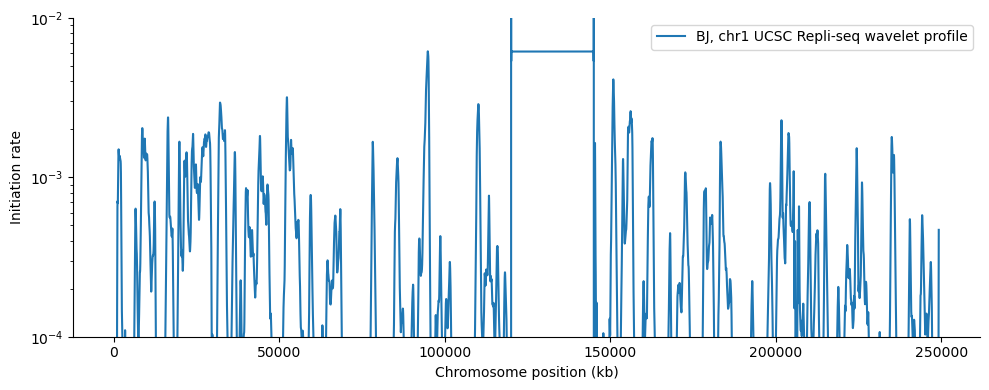

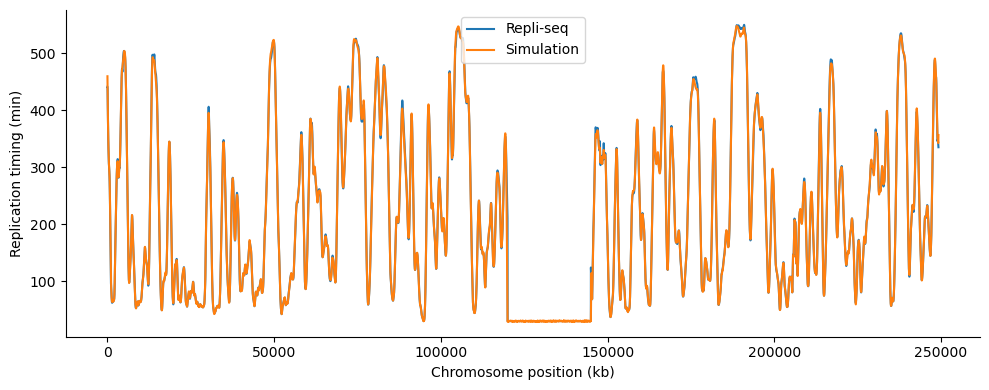

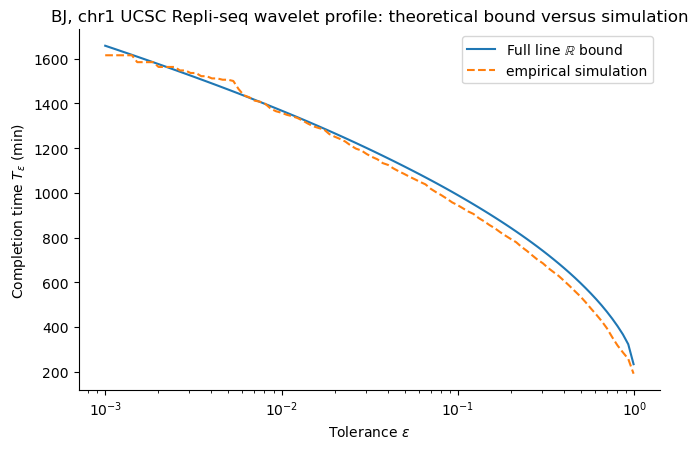

,dataset_key,dataset_label,geometry,dx_kb,fork_speed_kb_min,fork_speed_grid_per_min,E_theory_min,tail_fraction,E_empirical_pointwise_min,theory_over_empirical_pointwise
0,BJ_line_chr1,"BJ, chr1 UCSC Repli-seq wavelet profile",line,10.0,1.4,0.14,634.797832,0.0,548.033352,1.15832


In [6]:
make_standard_plots(
    line_result,
    save_figures=True,
    initiation_ylims=(1e-4, 1e-2),
    # initiation_ylim_percentiles=None,  # use manual y-limits exactly
)

expected_time_summary_table({LINE_KEY: line_result})

## A4. Full-line batch scatter across selected chr1 cell lines

Choose one or more UCSC Repli-seq cell lines, run the full-line chr1 analysis for those tracks, and show the empirical-versus-theoretical expected-time scatter. The batch uses the same A2 timing-preparation settings and centromere handling, and ignores those bins in both empirical and theoretical completion summaries.

In [7]:
LINE_BATCH_CELL_LINES = REPLISEQ_CELL_LINES
# LINE_BATCH_CELL_LINES = ["K562", "BJ"]
LINE_BATCH_CHROM = "chr1"
LINE_BATCH_SIM_NUMBER = 10
LINE_BATCH_REFINE_FACTOR = globals().get("LINE_ANALYSIS_REFINE_FACTOR", .1)
LINE_BATCH_SMOOTH_WINDOW = globals().get("LINE_ANALYSIS_SMOOTH_WINDOW", 250)
LINE_BATCH_TIMING_RANGE = globals().get("LINE_ANALYSIS_TIMING_RANGE", (150, 30))
LINE_BATCH_EPS_GRID = globals().get("LINE_ANALYSIS_EPS_GRID", np.geomspace(1e-3, 0.99, 100))
LINE_BATCH_NUM_T_BOUND = globals().get("LINE_ANALYSIS_NUM_T_BOUND", 4_000)
LINE_BATCH_MAX_REP_TIME = globals().get("LINE_ANALYSIS_MAX_REP_TIME", 2_000)

LINE_BATCH_KEYS = [
    f"{str(cell_line).upper().replace('-', '').replace('_', '').replace(' ', '')}_line_{safe_filename(LINE_BATCH_CHROM)}"
    for cell_line in LINE_BATCH_CELL_LINES
]
missing_line_batch_keys = [key for key in LINE_BATCH_KEYS if key not in LINE_PROFILE_DATASETS]
if missing_line_batch_keys:
    available = ", ".join(LINE_PROFILE_DATASETS)
    missing = ", ".join(missing_line_batch_keys)
    raise KeyError(f"Missing batch dataset key(s): {missing}. Available keys: {available}")

LINE_BATCH_DATASETS = {key: LINE_PROFILE_DATASETS[key] for key in LINE_BATCH_KEYS}
display(pd.DataFrame([
    {
        "key": key,
        "cell_line": cfg["cell_line"],
        "chromosome": cfg["chrom"],
        "resolution_bp": cfg["resolution"],
        "source_bigwig": cfg["source_bigwig"],
    }
    for key, cfg in LINE_BATCH_DATASETS.items()
]))

line_batch_results = run_dataset_collection(
    LINE_BATCH_DATASETS,
    selected_keys=LINE_BATCH_KEYS,
    fork_speed_kb_min=1.4,
    sim_number=LINE_BATCH_SIM_NUMBER,
    refine_factor=LINE_BATCH_REFINE_FACTOR,
    smooth_window=LINE_BATCH_SMOOTH_WINDOW,
    timing_range=LINE_BATCH_TIMING_RANGE,
    eps_grid=LINE_BATCH_EPS_GRID,
    num_t_bound=LINE_BATCH_NUM_T_BOUND,
    max_rep_time=LINE_BATCH_MAX_REP_TIME,
    timing_cache_mode="load",
    centromeres_bp=REPLISEQ_CENTROMERES_BP,
)

,key,cell_line,chromosome,resolution_bp,source_bigwig
0,BG02ES_line_chr1,BG02ES,chr1,1000,data\wgEncodeUwRepliSeqBg02esWaveSignalRep1.bi...
1,BJ_line_chr1,BJ,chr1,1000,data\wgEncodeUwRepliSeqBjWaveSignalRep1.bigWig
2,HELAS3_line_chr1,HELAS3,chr1,1000,data\wgEncodeUwRepliSeqHelas3WaveSignalRep1.bi...
3,HEPG2_line_chr1,HEPG2,chr1,1000,data\wgEncodeUwRepliSeqHepg2WaveSignalRep1.bigWig
4,HUVEC_line_chr1,HUVEC,chr1,1000,data\wgEncodeUwRepliSeqHuvecWaveSignalRep1.bigWig
5,IMR90_line_chr1,IMR90,chr1,1000,data\wgEncodeUwRepliSeqImr90WaveSignalRep1.bigWig
6,K562_line_chr1,K562,chr1,1000,data\wgEncodeUwRepliSeqK562WaveSignalRep1.bigWig
7,MCF7_line_chr1,MCF7,chr1,1000,data\wgEncodeUwRepliSeqMcf7WaveSignalRep1.bigWig
8,NHEK_line_chr1,NHEK,chr1,1000,data\wgEncodeUwRepliSeqNhekWaveSignalRep1.bigWig
9,SKNSH_line_chr1,SKNSH,chr1,1000,data\wgEncodeUwRepliSeqSknshWaveSignalRep1.bigWig


Processing: BG02ES, chr1 UCSC Repli-seq wavelet profile
Region: chr1:0-249250000
Model periodicity: fit=False, simulation=False
Bound geometries: ['line']
Loading raw timing CSV: timing\BG02ES_ucsc_wavelet_line_profile_chr1_0_249250000_res1000_raw_timing.csv
Centromere override: set 2,500 bins to pre-rescale maximum for timing minimum 77.9983 (30 min after rescaling)
Grid spacing: 10 kb per simulation site
Fork speed: 1.4 kb/min = 0.14 grid sites/min
T_epsilon summary: ignoring 2,500 centromere bins in empirical and theoretical calculations
Processing: BJ, chr1 UCSC Repli-seq wavelet profile
Region: chr1:0-249250000
Model periodicity: fit=False, simulation=False
Bound geometries: ['line']
Loading raw timing CSV: timing\BJ_ucsc_wavelet_line_profile_chr1_0_249250000_res1000_raw_timing.csv
Centromere override: set 2,500 bins to pre-rescale maximum for timing minimum 77.3333 (30 min after rescaling)
Grid spacing: 10 kb per simulation site
Fork speed: 1.4 kb/min = 0.14 grid sites/min
T_epsi

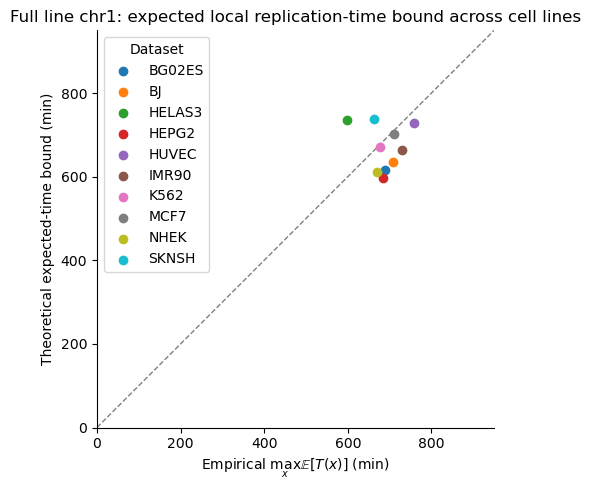

In [10]:
fig, ax, line_expected_time_pairs = plot_expected_time_pair_scatter(
    line_batch_results,
    title=f"Full line {LINE_BATCH_CHROM}: expected local replication-time bound across cell lines",
    label_col="cell_line",
    xlims=(0, 950),
    ylims=(0, 950),
)
fig.savefig(FIGURE_DIR / f"line_expected_time_pairs_{safe_filename(LINE_BATCH_CHROM)}.pdf", bbox_inches="tight")
plt.show()

# Analysis B: finite HCT116 chr8 intervals on the torus

For the finite-domain analyses, we use high-resolution HCT116 Repli-seq data from Zhao et al.~\cite{zhao2020high} over three chromosome~8 windows motivated by Jaworski et al.~\cite{jaworski2025ecdna}. These are the 7~Mb c-MYC/ecDNA context window `chr8:124,000,000--131,000,000`, the dominant ecDNA-derived interval `chr8:126,425,747--127,997,820`, and a c-MYC-centred subwindow corresponding to the origin-density zoom in that study, `chr8:127,675,747--127,775,747`. We treat these finite windows as synthetic periodic domains to test the torus estimates on circularised, amplicon-scale initiation landscapes. The simulations should therefore be interpreted as HCT116 Repli-seq-derived timing profiles evaluated on genomic intervals chosen from the chromosome~8 regions highlighted by the ecDNA study, rather than as purified ecDNA Repli-seq measurements.

## B1. Download and load Zhao HCT116 Repli-seq timing

Download the processed HCT116 Repli-seq matrix from GSE137764, reconstruct a timing value from the 16 S-phase signal rows, interpolate it to a 1 kb analysis grid, and cache one raw timing CSV for each selected chr8 finite window.

In [60]:
ZHAO_HCT116_GSE_ACCESSION = "GSE137764"
ZHAO_HCT116_REPLISEQ_URL = (
    "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE137nnn/GSE137764/suppl/"
    "GSE137764_HCT_GaussiansGSE137764_mooth_scaled_autosome.mat.gz"
)
ZHAO_HCT116_REPLISEQ_GZ = DATA_DIR / "GSE137764_HCT_GaussiansGSE137764_mooth_scaled_autosome.mat.gz"
ZHAO_HCT116_REPLISEQ_TABLE = DATA_DIR / "GSE137764_HCT_GaussiansGSE137764_mooth_scaled_autosome.mat"
ZHAO_HCT116_SOURCE_RESOLUTION = 50_000
ZHAO_HCT116_ANALYSIS_RESOLUTION = 1_000
ZHAO_HCT116_S_PHASE_BINS = [f"S{i}" for i in range(1, 17)]
ZHAO_HCT116_OVERWRITE_DOWNLOAD = False
ZHAO_HCT116_OVERWRITE_TIMING_CACHE = False


def ensure_zhao_hct116_repliseq(
    url=ZHAO_HCT116_REPLISEQ_URL,
    gz_path=ZHAO_HCT116_REPLISEQ_GZ,
    table_path=ZHAO_HCT116_REPLISEQ_TABLE,
    overwrite=False,
):
    DATA_DIR.mkdir(parents=True, exist_ok=True)

    if overwrite or not gz_path.exists():
        print(f"Downloading {ZHAO_HCT116_GSE_ACCESSION} HCT116 Repli-seq matrix -> {gz_path}")
        urlretrieve(url, gz_path)
    else:
        print(f"Already available: {gz_path}")

    if overwrite or not table_path.exists():
        print(f"Decompressing -> {table_path}")
        with gzip.open(gz_path, "rb") as src, open(table_path, "wb") as dst:
            shutil.copyfileobj(src, dst)
    else:
        print(f"Already decompressed: {table_path}")

    return table_path


def load_zhao_hct116_repliseq_matrix(path=ZHAO_HCT116_REPLISEQ_TABLE):
    rows = []
    with open(path, "rt", encoding="utf-8") as handle:
        for line in handle:
            rows.append(line.rstrip("\r\n").split("\t"))

    if len(rows) != 3 + len(ZHAO_HCT116_S_PHASE_BINS):
        raise ValueError(f"Expected 19 rows in {path}, found {len(rows)}")

    n_cols = len(rows[0])
    if any(len(row) != n_cols for row in rows[:3]):
        raise ValueError("The coordinate rows in the Zhao HCT116 matrix have inconsistent column counts")

    chroms = np.asarray(rows[0], dtype=str)
    starts = np.asarray(rows[1], dtype=np.int64)
    ends = np.asarray(rows[2], dtype=np.int64)

    signal_rows = []
    for row in rows[3:]:
        if len(row) != n_cols:
            raise ValueError("A signal row in the Zhao HCT116 matrix has an unexpected column count")
        signal_rows.append([float(value) if value else np.nan for value in row])

    signals = np.asarray(signal_rows, dtype=float)
    return {
        "chroms": chroms,
        "starts": starts,
        "ends": ends,
        "signals": signals,
        "s_phase_bins": ZHAO_HCT116_S_PHASE_BINS,
        "source_resolution": ZHAO_HCT116_SOURCE_RESOLUTION,
    }


def zhao_hct116_timing_from_signals(signals):
    signals = np.asarray(signals, dtype=float)
    bin_midpoints = np.arange(1, signals.shape[0] + 1, dtype=float)
    clean_signals = np.where(np.isfinite(signals), np.maximum(signals, 0.0), 0.0)
    weights = clean_signals.sum(axis=0)
    timing = np.full(signals.shape[1], np.nan, dtype=float)
    usable = weights > 0
    timing[usable] = (clean_signals[:, usable] * bin_midpoints[:, None]).sum(axis=0) / weights[usable]
    return timing


def zhao_hct116_region_timing(cfg, matrix, output_resolution=ZHAO_HCT116_ANALYSIS_RESOLUTION):
    chrom = cfg.get("requested_chrom", cfg["chrom"])
    chrom_mask = matrix["chroms"] == chrom
    if not np.any(chrom_mask):
        available = ", ".join(sorted(set(matrix["chroms"])))
        raise KeyError(f"{chrom} is not present in the Zhao HCT116 matrix. Available chromosomes: {available}")

    source_centers = (matrix["starts"][chrom_mask] + matrix["ends"][chrom_mask]) / 2.0
    source_timing = zhao_hct116_timing_from_signals(matrix["signals"][:, chrom_mask])
    finite = np.isfinite(source_timing)
    if finite.sum() < 2:
        raise ValueError(f"Not enough finite HCT116 timing values for {chrom}")

    positions = np.arange(int(cfg["start"]), int(cfg["end"]), int(output_resolution), dtype=np.int64)
    target_centers = positions + output_resolution / 2.0
    timing = np.interp(target_centers, source_centers[finite], source_timing[finite])
    return positions, timing


def build_zhao_hct116_periodic_configs(regions, resolution=ZHAO_HCT116_ANALYSIS_RESOLUTION):
    configs = {}
    for region in regions:
        requested_chrom = region["chrom"]
        region_id = region.get(
            "region_id",
            safe_filename(f"{requested_chrom}_{region['start']}_{region['end']}").upper(),
        )
        label = region.get("label", f"{requested_chrom}:{region['start']}-{region['end']}")
        short_label = region.get("short_label", label)
        key = f"HCT116_{region_id}"
        configs[key] = {
            "key": key,
            "label": f"HCT116, {label}",
            "short_label": f"HCT116 {short_label}",
            "point_label": f"HCT116 {short_label}",
            "cell_line": "HCT116",
            "chrom": requested_chrom,
            "requested_chrom": requested_chrom,
            "start": int(region["start"]),
            "end": int(region["end"]),
            "resolution": int(resolution),
            "fit_periodic": True,
            "sim_periodic": True,
            "bound_geometries": ["torus"],
            "analysis_type": "zhao_hct116_periodic_interval",
            "data_source": ZHAO_HCT116_GSE_ACCESSION,
            "source_resolution": ZHAO_HCT116_SOURCE_RESOLUTION,
            "timing_method": "weighted_mean_S1_to_S16_then_linear_interpolation",
        }
    return configs


def save_zhao_hct116_timing_csv(cfg, matrix, timing_dir=TIMING_DIR, overwrite=False):
    path = timing_cache_path(cfg, timing_dir=timing_dir)
    if path.exists() and not overwrite:
        print(f"Timing CSV already exists: {path}")
        return path, pd.read_csv(path), "exists"

    positions, timing_raw = zhao_hct116_region_timing(cfg, matrix, output_resolution=cfg["resolution"])
    table = timing_curve_table(cfg, positions, timing_raw)
    table["source_accession"] = cfg["data_source"]
    table["source_resolution_bp"] = cfg["source_resolution"]
    table["timing_method"] = cfg["timing_method"]
    path.parent.mkdir(parents=True, exist_ok=True)
    table.to_csv(path, index=False)
    print(f"Wrote raw timing CSV: {path} ({len(table):,} bins)")
    return path, table, "written"


def preprocess_zhao_hct116_timing_collection(configs, matrix, timing_dir=TIMING_DIR, overwrite=False):
    rows = []
    for key, cfg in configs.items():
        path, table, status = save_zhao_hct116_timing_csv(
            cfg,
            matrix,
            timing_dir=timing_dir,
            overwrite=overwrite,
        )
        rows.append({
            "dataset_key": key,
            "dataset_label": cfg["label"],
            "raw_timing_csv": str(path),
            "bins": len(table),
            "status": status,
        })
    return pd.DataFrame(rows)


zhao_hct116_table_path = ensure_zhao_hct116_repliseq(overwrite=ZHAO_HCT116_OVERWRITE_DOWNLOAD)
zhao_hct116_matrix = load_zhao_hct116_repliseq_matrix(zhao_hct116_table_path)

PERIODIC_CELL_LINES = ["HCT116"]
PERIODIC_REGIONS = [
    {
        "region_id": "CHR8_CMYC_7MB",
        "label": "chr8 c-MYC/ecDNA context window",
        "short_label": "chr8 c-MYC/ecDNA 7 Mb",
        "chrom": "chr8",
        "start": 124_000_000,
        "end": 131_000_000,
    },
    {
        "region_id": "CHR8_ECDNA_DOMINANT",
        "label": "chr8 dominant ecDNA-derived interval",
        "short_label": "chr8 dominant ecDNA interval",
        "chrom": "chr8",
        "start": 126_425_747,
        "end": 127_997_820,
    },
    {
        "region_id": "CHR8_CMYC_ORIGIN_ZOOM",
        "label": "chr8 c-MYC-centred origin-density zoom",
        "short_label": "chr8 c-MYC origin zoom",
        "chrom": "chr8",
        "start": 127_675_747,
        "end": 127_775_747,
    },
]

PERIODIC_INTERVAL_DATASETS = build_zhao_hct116_periodic_configs(
    PERIODIC_REGIONS,
    resolution=ZHAO_HCT116_ANALYSIS_RESOLUTION,
)

display(pd.DataFrame([
    {
        "key": key,
        "cell_line": cfg["cell_line"],
        "region": cfg["short_label"].replace(f"{cfg['cell_line']} ", ""),
        "coordinates": f"{cfg.get('requested_chrom', cfg['chrom'])}:{cfg['start']}-{cfg['end']}",
        "source_resolution_bp": cfg["source_resolution"],
        "analysis_resolution_bp": cfg["resolution"],
    }
    for key, cfg in PERIODIC_INTERVAL_DATASETS.items()
]))

display(timing_cache_table(PERIODIC_INTERVAL_DATASETS))

periodic_timing_preprocessing = preprocess_zhao_hct116_timing_collection(
    PERIODIC_INTERVAL_DATASETS,
    zhao_hct116_matrix,
    overwrite=ZHAO_HCT116_OVERWRITE_TIMING_CACHE,
)
display(periodic_timing_preprocessing)

Already available: data\GSE137764_HCT_GaussiansGSE137764_mooth_scaled_autosome.mat.gz
Already decompressed: data\GSE137764_HCT_GaussiansGSE137764_mooth_scaled_autosome.mat


,key,cell_line,region,coordinates,source_resolution_bp,analysis_resolution_bp
0,HCT116_CHR8_CMYC_7MB,HCT116,chr8 c-MYC/ecDNA 7 Mb,chr8:124000000-131000000,50000,1000
1,HCT116_CHR8_ECDNA_DOMINANT,HCT116,chr8 dominant ecDNA interval,chr8:126425747-127997820,50000,1000
2,HCT116_CHR8_CMYC_ORIGIN_ZOOM,HCT116,chr8 c-MYC origin zoom,chr8:127675747-127775747,50000,1000


,dataset_key,dataset_label,raw_timing_csv,exists
0,HCT116_CHR8_CMYC_7MB,"HCT116, chr8 c-MYC/ecDNA context window",timing\HCT116_zhao_hct116_periodic_interval_ch...,True
1,HCT116_CHR8_ECDNA_DOMINANT,"HCT116, chr8 dominant ecDNA-derived interval",timing\HCT116_zhao_hct116_periodic_interval_ch...,True
2,HCT116_CHR8_CMYC_ORIGIN_ZOOM,"HCT116, chr8 c-MYC-centred origin-density zoom",timing\HCT116_zhao_hct116_periodic_interval_ch...,False


Timing CSV already exists: timing\HCT116_zhao_hct116_periodic_interval_chr8_124000000_131000000_res1000_raw_timing.csv
Timing CSV already exists: timing\HCT116_zhao_hct116_periodic_interval_chr8_126425747_127997820_res1000_raw_timing.csv
Wrote raw timing CSV: timing\HCT116_zhao_hct116_periodic_interval_chr8_127675747_127775747_res1000_raw_timing.csv (100 bins)


,dataset_key,dataset_label,raw_timing_csv,bins,status
0,HCT116_CHR8_CMYC_7MB,"HCT116, chr8 c-MYC/ecDNA context window",timing\HCT116_zhao_hct116_periodic_interval_ch...,7000,exists
1,HCT116_CHR8_ECDNA_DOMINANT,"HCT116, chr8 dominant ecDNA-derived interval",timing\HCT116_zhao_hct116_periodic_interval_ch...,1573,exists
2,HCT116_CHR8_CMYC_ORIGIN_ZOOM,"HCT116, chr8 c-MYC-centred origin-density zoom",timing\HCT116_zhao_hct116_periodic_interval_ch...,100,written


## B2. Run one HCT116 finite-window analysis

Choose one cached HCT116 finite interval and run it as a synthetic periodic domain. The cached timing arrays are already on the 1 kb analysis grid, so `refine_factor=1` keeps the grid unchanged before smoothing and fitting.

In [63]:
PERIODIC_EXAMPLE_CELL_LINE = "HCT116"
PERIODIC_EXAMPLE_REGION_ID = "CHR8_CMYC_7MB"
PERIODIC_KEY = f"{PERIODIC_EXAMPLE_CELL_LINE}_{PERIODIC_EXAMPLE_REGION_ID}"

if PERIODIC_KEY not in PERIODIC_INTERVAL_DATASETS:
    available = ", ".join(PERIODIC_INTERVAL_DATASETS)
    raise KeyError(f"{PERIODIC_KEY} is not available. Available keys: {available}")

periodic_result = run_single_dataset(
    PERIODIC_INTERVAL_DATASETS[PERIODIC_KEY],
    fork_speed_kb_min=1.4,
    sim_number=10000,          # reduce during exploratory runs if needed
    refine_factor=1,           # cached Zhao HCT116 timing grid is already 1 kb
    smooth_window=10,
    timing_range=(60, 10),
    eps_grid=np.geomspace(1e-3, 0.99, 100),
    num_t_bound=4_000,
    max_rep_time=2_000,
    timing_cache_mode="load",
)

Processing: HCT116, chr8 c-MYC/ecDNA context window
Region: chr8:124000000-131000000
Model periodicity: fit=True, simulation=True
Bound geometries: ['torus']
Loading raw timing CSV: timing\HCT116_zhao_hct116_periodic_interval_chr8_124000000_131000000_res1000_raw_timing.csv
Grid spacing: 1 kb per simulation site
Fork speed: 1.4 kb/min = 1.4 grid sites/min


## B3. Plot and summarize the selected periodic result

Plot the standard diagnostics for the single periodic result from B2.

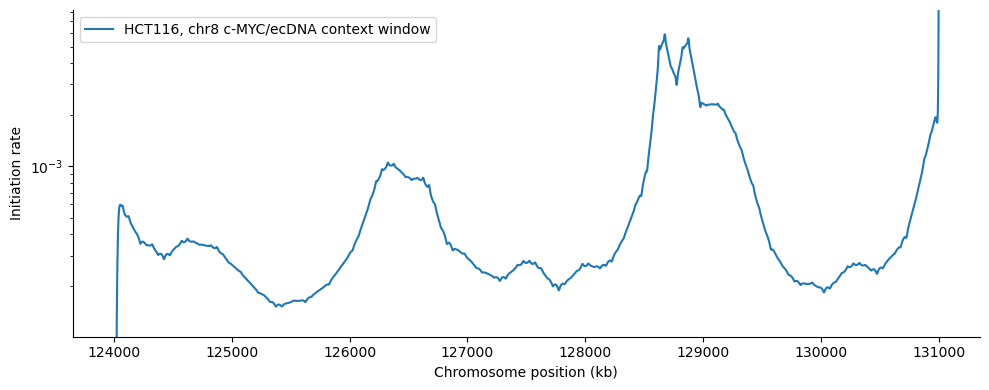

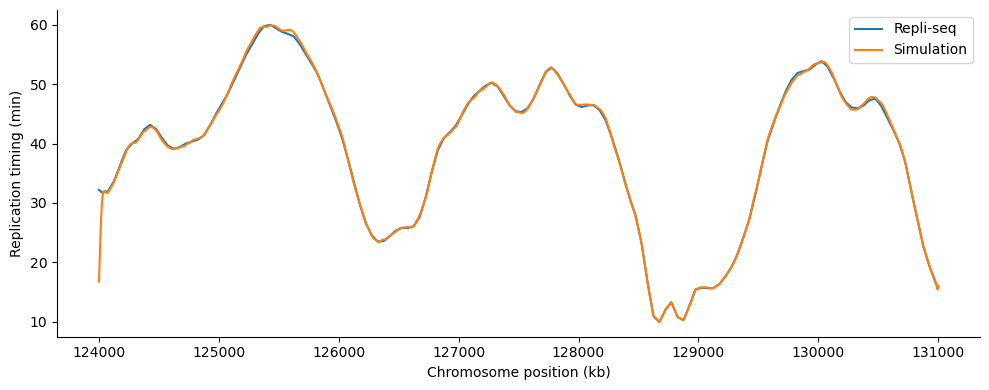

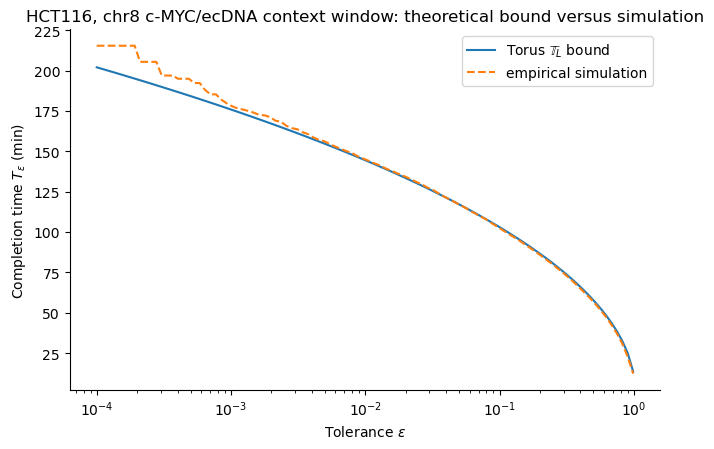

,dataset_key,dataset_label,geometry,dx_kb,fork_speed_kb_min,fork_speed_grid_per_min,E_theory_min,tail_fraction,E_empirical_pointwise_min,theory_over_empirical_pointwise
0,HCT116_CHR8_CMYC_7MB,"HCT116, chr8 c-MYC/ecDNA context window",torus,1.0,1.4,1.4,61.626067,0.0,59.909865,1.028646


In [64]:
make_standard_plots(
    periodic_result,
    save_figures=True,
    # initiation_ylims=(1e-8, 1e-3),
    # initiation_ylim_percentiles=None,  # use manual y-limits exactly
)

expected_time_summary_table({PERIODIC_KEY: periodic_result})

## B4. HCT116 chr8 finite-window batch scatter

Run the three selected HCT116 chr8 finite windows and show the empirical-versus-theoretical expected-time scatter for the torus bound.

In [65]:
PERIODIC_BATCH_DATASETS = PERIODIC_INTERVAL_DATASETS

periodic_batch_results = run_dataset_collection(
    PERIODIC_BATCH_DATASETS,
    selected_keys=list(PERIODIC_BATCH_DATASETS),
    fork_speed_kb_min=1.4,
    sim_number=1000,
    refine_factor=1,
    smooth_window=50,
    timing_range=(60, 10),
    eps_grid=np.geomspace(1e-4, 0.99, 100),
    num_t_bound=4_000,
    max_rep_time=2_000,
    timing_cache_mode="load",
)

Processing: HCT116, chr8 c-MYC/ecDNA context window
Region: chr8:124000000-131000000
Model periodicity: fit=True, simulation=True
Bound geometries: ['torus']
Loading raw timing CSV: timing\HCT116_zhao_hct116_periodic_interval_chr8_124000000_131000000_res1000_raw_timing.csv
Grid spacing: 1 kb per simulation site
Fork speed: 1.4 kb/min = 1.4 grid sites/min
Processing: HCT116, chr8 dominant ecDNA-derived interval01
Region: chr8:126425747-127997820
Model periodicity: fit=True, simulation=True
Bound geometries: ['torus']
Loading raw timing CSV: timing\HCT116_zhao_hct116_periodic_interval_chr8_126425747_127997820_res1000_raw_timing.csv
Grid spacing: 1 kb per simulation site
Fork speed: 1.4 kb/min = 1.4 grid sites/min
Processing: HCT116, chr8 c-MYC-centred origin-density zoom
Region: chr8:127675747-127775747
Model periodicity: fit=True, simulation=True
Bound geometries: ['torus']
Loading raw timing CSV: timing\HCT116_zhao_hct116_periodic_interval_chr8_127675747_127775747_res1000_raw_timing.cs

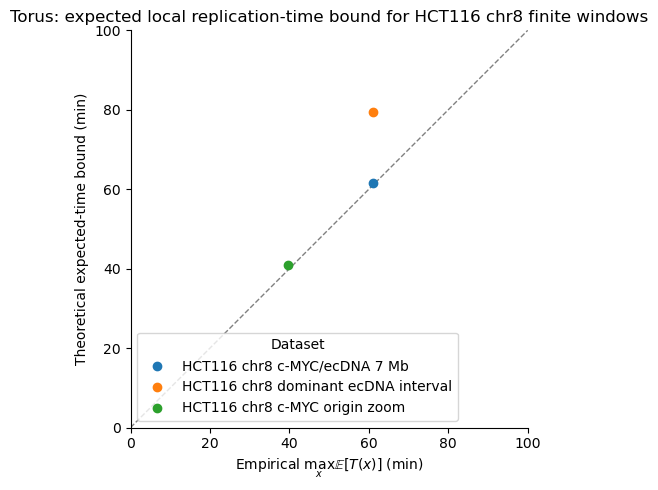

In [66]:
fig, ax, periodic_expected_time_pairs = plot_expected_time_pair_scatter(
    periodic_batch_results,
    title="Torus: expected local replication-time bound for HCT116 chr8 finite windows",
    xlims=(0, 100),
    ylims=(0, 100),
)
fig.savefig(FIGURE_DIR / "hct116_chr8_three_windows_torus_expected_time_pairs.pdf", bbox_inches="tight")
plt.show()

# Notes on interpretation

For non-periodic chromosome profiles, the simulation is run with `perQ=False` and the comparison is made with the full-line completion bound. The local initiation mass is computed using non-wrapping intervals in the observed chromosome, not circular arcs. This keeps the analysis aligned with the line geometry.

For the HCT116 chr8 finite-window profiles, the torus completion bound is the natural theoretical object because each selected interval is being analysed as a circularised synthetic domain. The fit and stochastic simulations are therefore run with `perQ=True`. These are HCT116 Repli-seq-derived genomic-window analyses, not purified ecDNA Repli-seq measurements.

In both sections, the code converts the physical fork speed in kb/min into grid units using

$$
v_{\text{grid}} = \frac{v_{\text{kb/min}}}{dx_{\text{kb}}}.
$$

and uses this grid speed in both the stochastic simulations and the theoretical bound. The local initiation mass is computed in grid units, so fitted initiation rates are not multiplied by the input bin size. The kb conversion is used only for plotting lengths.

The expected-time summary is obtained by integrating the same survival upper bound used for the completion-time curves. It therefore matches the pointwise-uniform logic and bounds the slowest expected local replication time `max_x E[T(x)]`. For full citation details, see the README references: initiation-rate fitting follows [Berkemeier et al. (2025)](https://www.nature.com/articles/s41467-025-59991-w), and the completion-bound comparison follows Alkhaled, Berkemeier & Nik (2026).